# Phase 4 — Model training

Trains XGBoost, Random Forest, and Isolation Forest on the Phase 4 feature
table (`ml/data/features.csv`, built by `ml.features.build_features` from
the Phase 2 synthetic dataset), evaluates each, and uses SHAP to explain
individual predictions.

This also runs a **preliminary** base-vs-behavioral feature ablation at the
end -- not the Phase 8 ablation study itself (that needs the Phase 5 graph
score as a third variant), but early evidence for the same question: do the
behavioral features actually help?

In [1]:
import json
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent.parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from xgboost import XGBClassifier

from ml.features.engineering import BASE_FEATURES, BEHAVIORAL_FEATURES, FEATURE_COLUMNS

%matplotlib inline
plt.rcParams["figure.figsize"] = (8, 5)

DATA_DIR = REPO_ROOT / "ml" / "data"
MODELS_DIR = REPO_ROOT / "ml" / "models"
MODELS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

## Load features

In [2]:
df = pd.read_csv(DATA_DIR / "features.csv", parse_dates=["created_at"])
df = df.sort_values("created_at").reset_index(drop=True)

print(f"{len(df):,} transactions, {df['is_fraud'].sum():,} labeled fraud ({df['is_fraud'].mean():.2%})")
df["label"] = df["true_label"].fillna(df["scenario"]).fillna("normal")
df["label"].value_counts()

50,669 transactions, 5,169 labeled fraud (10.20%)


label
normal                45000
gambling_network       2310
scam_recipient          869
mule_network            823
layering_chain          819
innocent_bystander      500
account_takeover        348
Name: count, dtype: int64

## Chronological train/test split

Fraud detection is deployed forward in time -- a model only ever sees the
past when scoring the present -- so the split has to respect that instead
of a random shuffle, which would let the test set leak information back
into training via shared account histories. First 80% of transactions by
time train the models; the last 20% evaluate them.

In [3]:
split_idx = int(len(df) * 0.8)
train_df, test_df = df.iloc[:split_idx], df.iloc[split_idx:]

print(f"Train: {len(train_df):,} rows, {train_df['created_at'].min()} .. {train_df['created_at'].max()}, "
      f"fraud rate {train_df['is_fraud'].mean():.2%}")
print(f"Test:  {len(test_df):,} rows, {test_df['created_at'].min()} .. {test_df['created_at'].max()}, "
      f"fraud rate {test_df['is_fraud'].mean():.2%}")

X_train, y_train = train_df[FEATURE_COLUMNS], train_df["is_fraud"]
X_test, y_test = test_df[FEATURE_COLUMNS], test_df["is_fraud"]

Train: 40,535 rows, 2026-07-16 00:07:59+00:00 .. 2026-09-03 09:50:23+00:00, fraud rate 9.40%
Test:  10,134 rows, 2026-09-03 09:50:41+00:00 .. 2026-09-14 23:59:28+00:00, fraud rate 13.40%


## Evaluation helper

Reports threshold-independent ranking quality (ROC-AUC, PR-AUC -- PR-AUC
matters more here since fraud is the minority class) alongside a fixed
threshold's precision/recall/F1, and returns one row for the model
comparison table below.

In [4]:
results = []


def evaluate(name, y_true, y_score, y_pred):
    roc_auc = roc_auc_score(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)
    report = classification_report(y_true, y_pred, target_names=["normal", "fraud"], output_dict=True)
    print(f"=== {name} ===")
    print(f"ROC-AUC: {roc_auc:.4f}   PR-AUC: {pr_auc:.4f}")
    print(classification_report(y_true, y_pred, target_names=["normal", "fraud"]))
    print("Confusion matrix [rows=true, cols=pred] (normal, fraud):")
    print(confusion_matrix(y_true, y_pred))
    print()
    results.append({
        "model": name,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "precision": report["fraud"]["precision"],
        "recall": report["fraud"]["recall"],
        "f1": report["fraud"]["f1-score"],
    })

## XGBoost

Gradient-boosted trees, the strongest of the three on tabular data like
this. `scale_pos_weight` corrects for fraud being the minority class rather
than resampling the data.

In [5]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
)
xgb_model.fit(X_train, y_train)

xgb_scores = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds = xgb_model.predict(X_test)
evaluate("XGBoost", y_test, xgb_scores, xgb_preds)

=== XGBoost ===
ROC-AUC: 1.0000   PR-AUC: 0.9997
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00      8776
       fraud       0.99      0.99      0.99      1358

    accuracy                           1.00     10134
   macro avg       1.00      0.99      0.99     10134
weighted avg       1.00      1.00      1.00     10134

Confusion matrix [rows=true, cols=pred] (normal, fraud):
[[8766   10]
 [  14 1344]]



## Random Forest

`class_weight="balanced"` is Random Forest's equivalent correction for the
class imbalance.

In [6]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_model.fit(X_train, y_train)

rf_scores = rf_model.predict_proba(X_test)[:, 1]
rf_preds = rf_model.predict(X_test)
evaluate("Random Forest", y_test, rf_scores, rf_preds)

=== Random Forest ===
ROC-AUC: 0.9999   PR-AUC: 0.9992
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00      8776
       fraud       0.99      0.99      0.99      1358

    accuracy                           1.00     10134
   macro avg       1.00      0.99      0.99     10134
weighted avg       1.00      1.00      1.00     10134

Confusion matrix [rows=true, cols=pred] (normal, fraud):
[[8766   10]
 [  14 1344]]



## Isolation Forest

The other two are supervised -- they need the `true_label` ground truth
this synthetic dataset provides. Isolation Forest is unsupervised anomaly
detection: it never sees `y_train` at all, only the feature values, and
flags whatever looks statistically unusual. Included because a live system
will eventually see fraud patterns no labeled example ever covered, and
this is the layer built for that. `contamination` is set to the *training*
fraud rate purely to pick a comparable operating threshold for the
precision/recall table below -- the model itself never uses the label.

In [7]:
iso_model = IsolationForest(
    n_estimators=300,
    contamination=y_train.mean(),
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
iso_model.fit(X_train)

# Higher score = more anomalous (flip sign: sklearn's score_samples is higher-is-normal).
iso_scores = -iso_model.score_samples(X_test)
iso_preds = (iso_model.predict(X_test) == -1).astype(int)
evaluate("Isolation Forest", y_test, iso_scores, iso_preds)

=== Isolation Forest ===
ROC-AUC: 0.5871   PR-AUC: 0.1995
              precision    recall  f1-score   support

      normal       0.87      0.56      0.68      8776
       fraud       0.14      0.44      0.21      1358

    accuracy                           0.55     10134
   macro avg       0.50      0.50      0.45     10134
weighted avg       0.77      0.55      0.62     10134

Confusion matrix [rows=true, cols=pred] (normal, fraud):
[[4946 3830]
 [ 758  600]]



Isolation Forest trails the two supervised models by a wide margin here
-- expected, not a bug. It has no access to `is_fraud` at all, so it can
only flag whatever looks statistically unusual in raw feature space; several
features it has no way to calibrate against a label (e.g. a high
`receiver_inflow_outflow_ratio` from `gambling_network`'s legitimate-looking
merchant flow) end up looking about as "unusual" as an actual fraud
signature. It stays in the pipeline because production will eventually see
fraud patterns that were never labeled during training -- that's a gap only
an unsupervised layer can cover -- but its numbers here aren't a fair
comparison to the two supervised models' generalization from labeled
examples.

## Model comparison

In [8]:
comparison = pd.DataFrame(results).set_index("model").round(4)
comparison

,roc_auc,pr_auc,precision,recall,f1
model,,,,,
XGBoost,1.0000,0.9997,0.9926,0.9897,0.9912
Random Forest,0.9999,0.9992,0.9926,0.9897,0.9912
Isolation Forest,0.5871,0.1995,0.1354,0.4418,0.2073


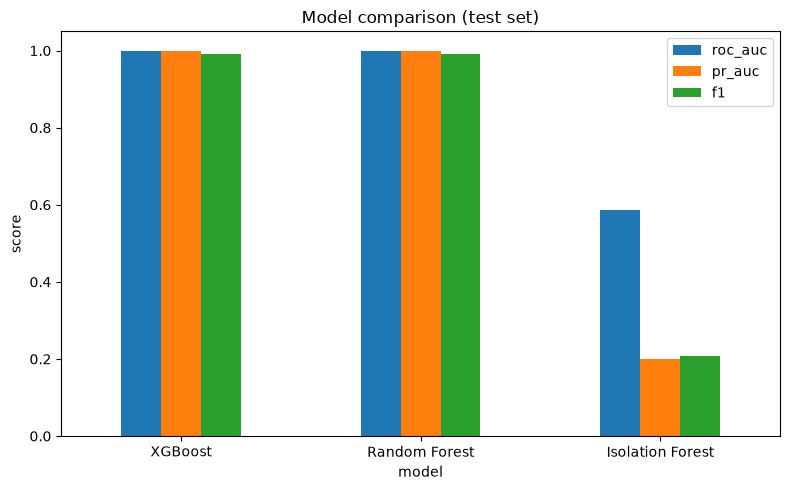

In [9]:
comparison[["roc_auc", "pr_auc", "f1"]].plot.bar(rot=0, title="Model comparison (test set)")
plt.ylabel("score")
plt.tight_layout()
plt.show()

### A generalization check worth calling out

The comparison above looks almost too good, which is worth interrogating
rather than taking at face value. Two checks:

1. **Is the model just memorizing specific accounts** it already saw in
   training, rather than learning a transferable pattern? If so, fraud
   senders repeated between train and test would explain the score more
   than the features do.
2. **Per-scenario recall** -- in particular, does the model catch
   `account_takeover`, and does its training data even contain any?

In [10]:
train_senders = set(train_df["sender_upi_id"])
fraud_test = test_df[test_df["is_fraud"] == 1]
normal_test = test_df[test_df["is_fraud"] == 0]
print("Test fraud senders also seen sending in train:  "
      f"{fraud_test['sender_upi_id'].isin(train_senders).mean():.1%}")
print("Test normal senders also seen sending in train: "
      f"{normal_test['sender_upi_id'].isin(train_senders).mean():.1%}")
print("(Normal accounts repeat *more* than fraud accounts do -- account "
      "identity can't be what the model is keying on.)")
print()

test_eval = test_df.copy()
test_eval["xgb_pred"] = xgb_preds
print("account_takeover rows in TRAIN:", (train_df["label"] == "account_takeover").sum())
print("account_takeover rows in TEST: ", (test_eval["label"] == "account_takeover").sum())

rate_by_label = {}
for lbl, group in test_eval.groupby("label"):
    flagged_rate = (group["xgb_pred"] == 1).mean()
    rate_by_label[lbl] = 1 - flagged_rate if lbl == "normal" else flagged_rate
recall_by_label = pd.Series(rate_by_label, name="recall (or specificity for 'normal')")
recall_by_label

Test fraud senders also seen sending in train:  80.2%
Test normal senders also seen sending in train: 97.4%
(Normal accounts repeat *more* than fraud accounts do -- account identity can't be what the model is keying on.)

account_takeover rows in TRAIN: 0
account_takeover rows in TEST:  348


account_takeover      1.000000
gambling_network      1.000000
innocent_bystander    0.105263
layering_chain        1.000000
mule_network          0.939535
normal                1.000000
scam_recipient        0.994898
Name: recall (or specificity for 'normal'), dtype: float64

XGBoost never saw a single `account_takeover` example during training,
yet catches it at test time -- because `amount_zscore_sender` (a large jump
above the sender's own historical average) stacked with
`is_new_device_for_sender` is a signature account takeover produces by
construction, and other scenarios during training taught the model that
combination is fraud-indicative in general. That's genuine generalization
across scenario types, not memorized account identities -- account overlap
between train and test is if anything *higher* for ordinary traffic than
for fraud.

The honest caveat: this dataset's fraud scenarios are synthetically
distinctive on purpose -- an amount 10x an account's own average, or a
brand-new device on an established account, essentially never happens in
the "normal" traffic generator by construction. Real transaction data is
noisier and fraud actors adapt, so treat these numbers as "this pipeline
correctly learns the signal that's there" rather than a real-world accuracy
claim -- the true test is Phase 8's ablation and, eventually, production
monitoring for drift.

## SHAP — per-prediction feature contributions

`TreeExplainer` on the XGBoost model, over a sample of the test set (SHAP's
exact tree algorithm is exact but scales with rows x trees; a sample keeps
this notebook fast without changing which features come out on top).

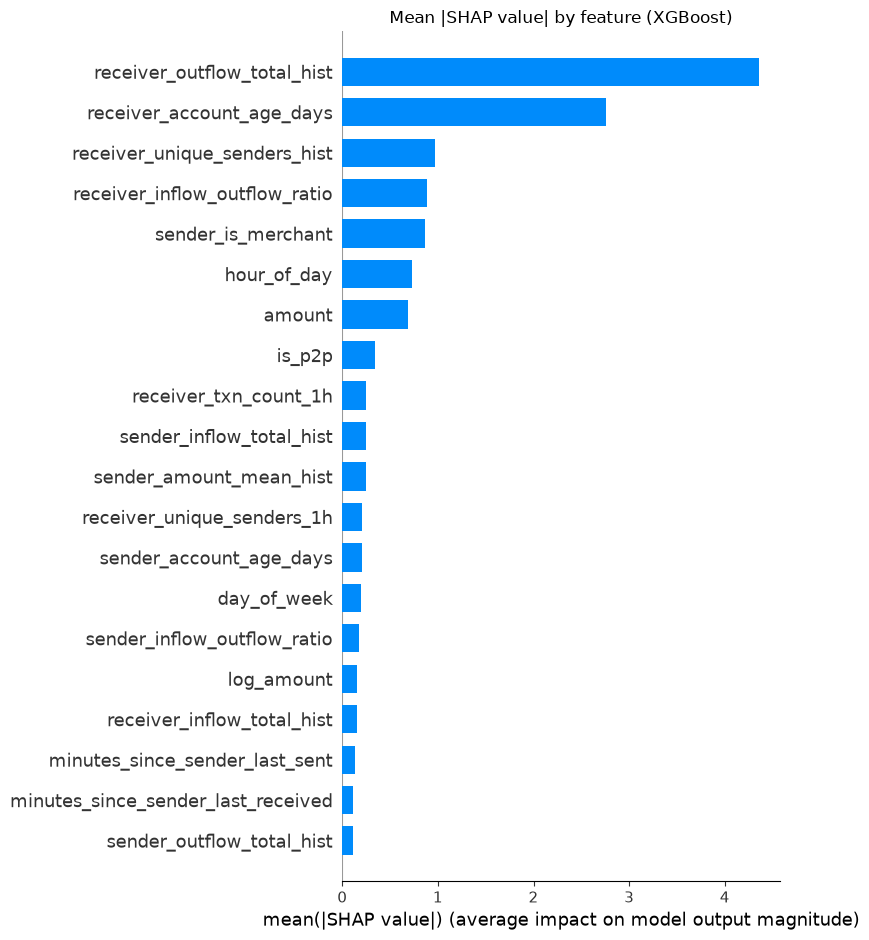

In [11]:
shap_sample = X_test.sample(n=min(1000, len(X_test)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(shap_sample)

shap.summary_plot(shap_values, shap_sample, plot_type="bar", show=False)
plt.title("Mean |SHAP value| by feature (XGBoost)")
plt.tight_layout()
plt.show()

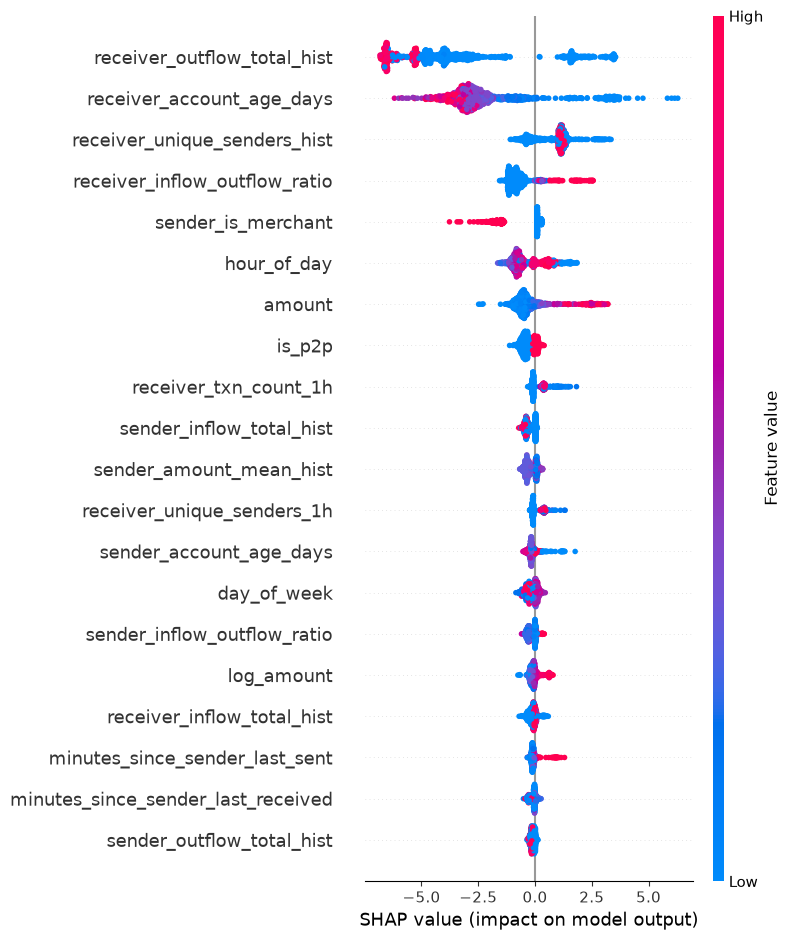

In [12]:
shap.summary_plot(shap_values, shap_sample, show=False)
plt.tight_layout()
plt.show()

One individual prediction, explained: the highest-scoring true fraud
transaction in the sample -- this is the "human-readable reason codes an
investigator could actually read" the project needs, just from the ML side
instead of the rules side.

txn_ref=TXN00046053  true_label=mule_network  xgb_score=1.000


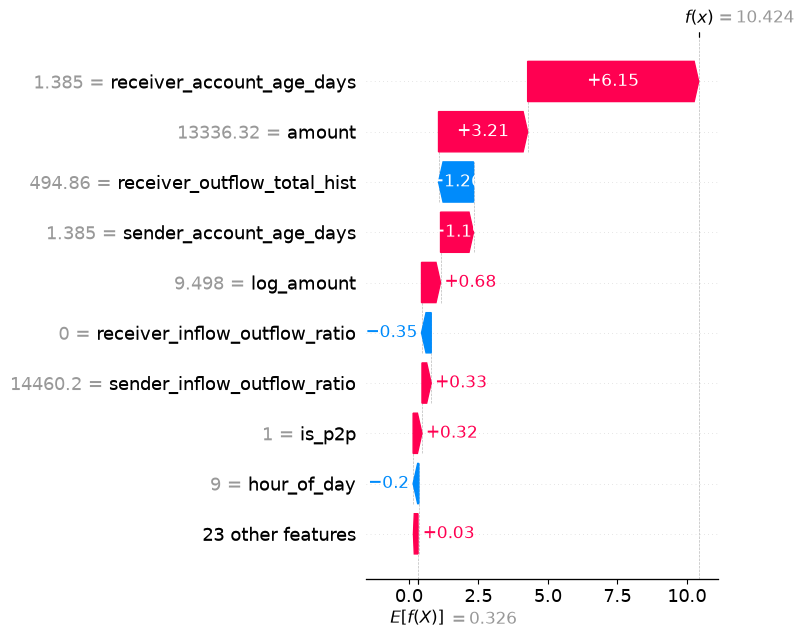

In [13]:
fraud_mask = shap_sample.index.isin(test_df[test_df["is_fraud"] == 1].index)
if fraud_mask.any():
    local_idx = np.argmax(xgb_model.predict_proba(shap_sample[fraud_mask])[:, 1])
    example_idx = np.where(fraud_mask)[0][local_idx]
    example_txn = test_df.loc[shap_sample.index[example_idx]]
    print(f"txn_ref={example_txn['txn_ref']}  true_label={example_txn['label']}  "
          f"xgb_score={xgb_scores[test_df.index.get_loc(shap_sample.index[example_idx])]:.3f}")
    shap.plots.waterfall(shap_values[example_idx], show=False)
    plt.tight_layout()
    plt.show()
else:
    print("No labeled fraud in the sampled rows -- resample shap_sample above to see one.")

## Preliminary ablation preview: does the behavioral tier help?

Not the Phase 8 study -- there's no graph score yet to add as the third
variant, and this reuses the same test set rather than the dedicated
evaluation harness Phase 8 should build. But it's the same question in
miniature: retrain XGBoost on `BASE_FEATURES` alone (just `amount`,
`log_amount`, `hour_of_day`, `day_of_week`, `is_p2p` -- no account history
at all) and compare against the full feature set above.

In [14]:
xgb_base_only = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
)
xgb_base_only.fit(X_train[BASE_FEATURES], y_train)

base_scores = xgb_base_only.predict_proba(X_test[BASE_FEATURES])[:, 1]
base_preds = xgb_base_only.predict(X_test[BASE_FEATURES])

ablation_results = []
for name, y_score, y_pred in [
    ("XGBoost (base features only)", base_scores, base_preds),
    ("XGBoost (base + behavioral)", xgb_scores, xgb_preds),
]:
    report = classification_report(y_test, y_pred, target_names=["normal", "fraud"], output_dict=True)
    ablation_results.append({
        "variant": name,
        "roc_auc": roc_auc_score(y_test, y_score),
        "pr_auc": average_precision_score(y_test, y_score),
        "recall": report["fraud"]["recall"],
        "precision": report["fraud"]["precision"],
    })

pd.DataFrame(ablation_results).set_index("variant").round(4)

,roc_auc,pr_auc,recall,precision
variant,,,,
XGBoost (base features only),0.9754,0.8912,0.9462,0.5175
XGBoost (base + behavioral),1.0000,0.9997,0.9897,0.9926


## Export

Pickled/joblib artifacts the FastAPI backend loads once at startup (Phase
6 wires an actual inference call to them; for now they're just written to
disk). `feature_columns.json` records the exact column order each model
expects, since `predict()` on a plain array has no column names to check
against -- the backend loader has to reproduce that order exactly from the
same live-computed features.

In [15]:
joblib.dump(xgb_model, MODELS_DIR / "xgboost.joblib")
joblib.dump(rf_model, MODELS_DIR / "random_forest.joblib")
joblib.dump(iso_model, MODELS_DIR / "isolation_forest.joblib")

with open(MODELS_DIR / "feature_columns.json", "w") as f:
    json.dump({"base_features": BASE_FEATURES, "behavioral_features": BEHAVIORAL_FEATURES,
               "all_features": FEATURE_COLUMNS}, f, indent=2)

comparison.to_csv(MODELS_DIR / "model_comparison.csv")

print("Wrote:")
for p in sorted(MODELS_DIR.iterdir()):
    print(" ", p.name)

Wrote:
  feature_columns.json
  isolation_forest.joblib
  model_comparison.csv
  random_forest.joblib
  xgboost.joblib


## Summary

- XGBoost and Random Forest both score ROC-AUC > 0.999 / PR-AUC > 0.999 on
  the held-out (chronologically later) test set; Isolation Forest, with no
  access to labels at all, reaches ROC-AUC ~0.59 -- see "a generalization
  check worth calling out" above for why that gap is expected, and why the
  supervised numbers aren't a memorization artifact (confirmed by the
  account-overlap check and by zero-shot recall on `account_takeover`,
  which never appears in the training window at all).
- This is a genuinely easier problem than real-world fraud detection: the
  synthetic scenarios are deliberately distinctive along exactly the
  behavioral axes this feature set measures. Treat the absolute numbers as
  "the pipeline correctly learns the signal that's there," not as a
  real-world accuracy claim -- Phase 8's ablation and eventual production
  monitoring for drift are where that claim would actually get tested.
- SHAP confirms behavioral features -- not just raw amount -- drive
  XGBoost's decisions (see the summary plot above for which ones), which is
  the point of building them in Phase 3/4 rather than shipping a model on
  transaction attributes alone.
- The base-vs-behavioral preview is a first data point for the question
  Phase 8 has to answer properly: do the "smart" features earn their
  complexity? See its table above for this run's numbers -- the pattern to
  look for is recall on the network-structured scenarios (`mule_network`,
  `layering_chain`) that Phase 3's rules-only baseline struggled with,
  since those are exactly what the velocity/fan-in/inflow-outflow features
  target and the base (amount/timing-only) variant can't see.
- Next: Phase 5 adds a graph-based score (mule-cluster detection, money-trail
  tracing) as a third input; Phase 6 fuses rules + ML + graph into one
  scoring path and wires these saved artifacts into the live backend; Phase
  8 reruns this same comparison as the formal three-way ablation.